# Artificial Non-Streaming Demo

This notebook mirrors the lean ZINC non-streaming demo, but uses an artificial NetworkX dataset generated in memory.

- source: cycle -> connector path -> star-ray graphs
- sample count: `DATASET_SIZE`
- fit mode: materialize generated graphs, then train normally
- outputs: 7 samples without feasibility filtering, then 7 with filtering


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import sys
from IPython.core.display import HTML
from pathlib import Path
import random
import warnings
import numpy as np

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

warnings.filterwarnings('ignore', message=r".*`isinstance\(treespec, LeafSpec\)` is deprecated.*")

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'conditional_node_field_graph_generator').is_dir():
        repo_root = candidate.resolve()
        break
else:
    raise RuntimeError(
        'Could not locate the NodeField repository from the current working directory. '
        'Start Jupyter from the repo root or the notebooks directory.'
    )

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator
from conditional_node_field_graph_generator.extensions.synthetic import generate_artificial_dataset


PyTorch version: 2.11.0+cu128
CUDA available: True


In [2]:
RANDOM_SEED = 42
DATASET_SIZE = 9000
CYCLE_LENGTH = 4
NUM_CYCLES = 1
PATH_LENGTH = (2,6)
NUM_RAYS = 2
RAY_LENGTH = 1
NODE_ALPHABET_SIZE = 3
EDGE_ALPHABET_SIZE = 1
NODE_ALPHABET_KIND = 'int'
EDGE_ALPHABET_KIND = 'int'
COMPONENT_SPECIFIC_ALPHABETS = True
FIT_BATCH_SIZE = 128
MAXIMUM_EPOCHS = 350
LOSS_CURVES_PDF_EVERY_N_EPOCHS = 10
EMBEDDING_DIM = 128
CYCLE_COUNT_TOKEN = '' if NUM_CYCLES == 1 else f'-nc{NUM_CYCLES}'
MODEL_NAME = (
    f'artificial-cycle-path-star-n{DATASET_SIZE}'
    f'-c{CYCLE_LENGTH}{CYCLE_COUNT_TOKEN}-p{PATH_LENGTH}-r{NUM_RAYS}x{RAY_LENGTH}'
    f'-d{EMBEDDING_DIM}-b{FIT_BATCH_SIZE}-e{MAXIMUM_EPOCHS}'
)
DECODER_N_JOBS = -1

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)




Saved artificial dataset config: artificial-cycle-path-star-n9000-c4-p2-6-r2x1-na3.yaml
Loaded 9000 artificial graphs into memory for non-streaming fit.
Node count min/median/max = 8/10/12
Edge count min/median/max = 8/10/12
Metadata: {'cycle_length': 4, 'num_cycles': 1, 'path_length': 2, 'num_rays': 2, 'ray_length': 1, 'node_alphabet_size': 3, 'edge_alphabet_size': 1, 'component_specific_alphabets': True, 'node_alphabets_by_component': {'cycle': [0, 1, 2], 'path': [3, 4, 5], 'star': [6, 7, 8]}, 'edge_alphabets_by_component': {'cycle': [0], 'path': [1], 'star': [2]}}
Configured graph generator model_name=artificial-cycle-path-star-n9000-c4-p-2-6-r2x1-d128-b128-e350 model_dir=/cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators
Training sample PDF: /cs0eth/home/fc334/code/NodeField/.artifacts/samples/artificial-cycle-path-star-n9000-c4-p(2, 6)-r2x1-d128-b128-e350/training_samples.pdf


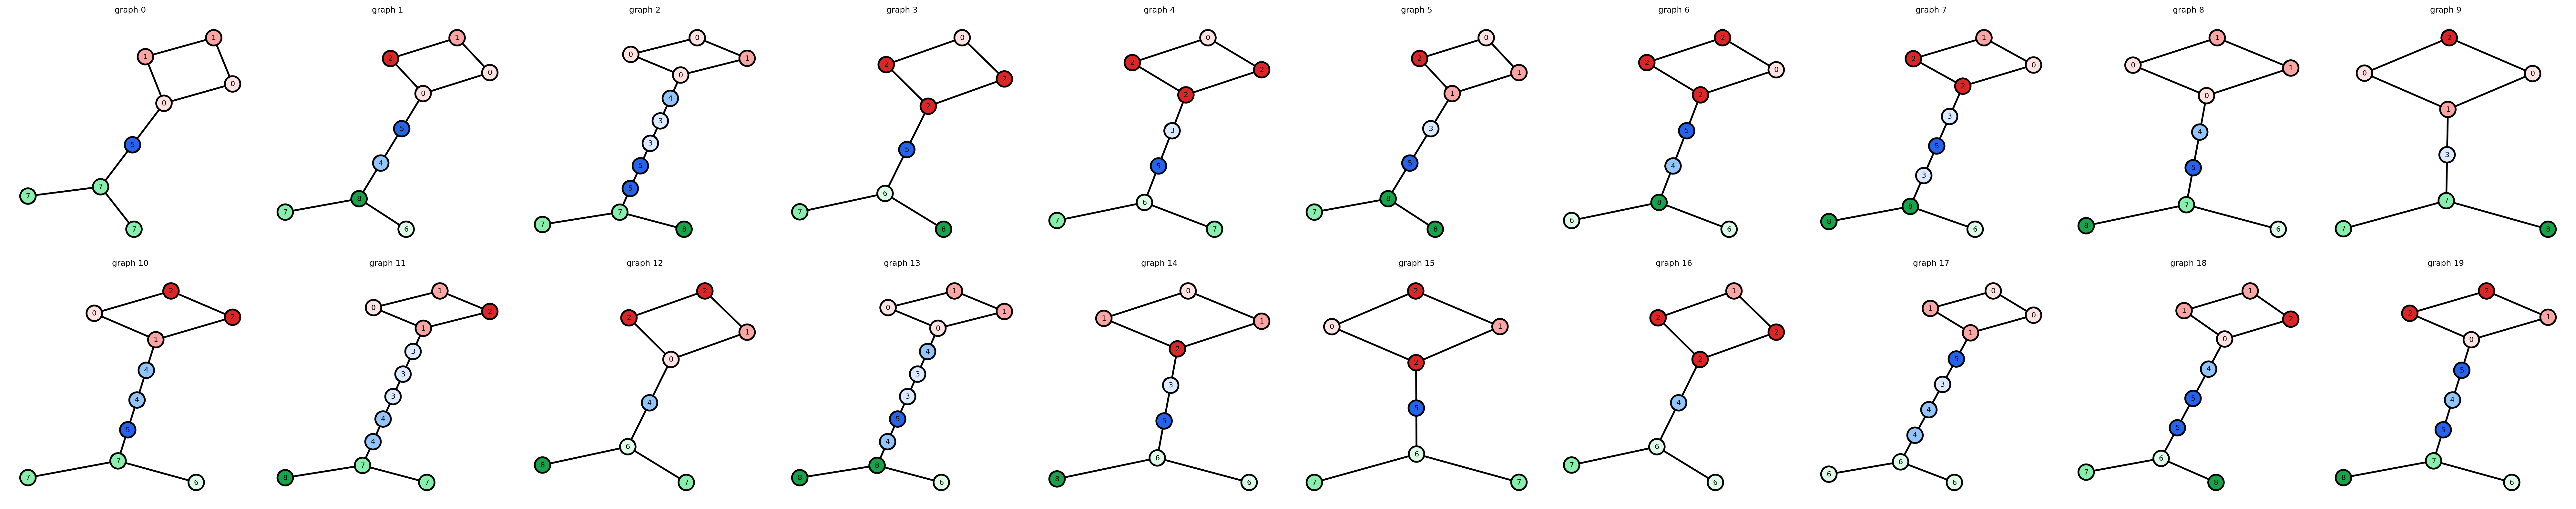

In [3]:
graphs, plot_artificial_graphs = generate_artificial_dataset(
    num_graphs=DATASET_SIZE,
    cycle_length=CYCLE_LENGTH,
    num_cycles=NUM_CYCLES,
    path_length=PATH_LENGTH,
    num_rays=NUM_RAYS,
    ray_length=RAY_LENGTH,
    node_alphabet_size=NODE_ALPHABET_SIZE,
    edge_alphabet_size=EDGE_ALPHABET_SIZE,
    node_alphabet_kind=NODE_ALPHABET_KIND,
    edge_alphabet_kind=EDGE_ALPHABET_KIND,
    component_specific_alphabets=COMPONENT_SPECIFIC_ALPHABETS,
    seed=RANDOM_SEED,
)

node_counts = np.array([graph.number_of_nodes() for graph in graphs])
edge_counts = np.array([graph.number_of_edges() for graph in graphs])
print(f'Loaded {len(graphs)} artificial graphs into memory for non-streaming fit.')
print(f'Node count min/median/max = {node_counts.min()}/{np.median(node_counts):.0f}/{node_counts.max()}')
print(f'Edge count min/median/max = {edge_counts.min()}/{np.median(edge_counts):.0f}/{edge_counts.max()}')
print('Metadata:', graphs[0].graph['metadata'])

plot_artificial_graphs(
    graphs[:20],
    n_cols=10,
    titles=[f'graph {idx}' for idx in range(20)],
)

graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    node_embedding_svd_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=3,
    transformer_attention_head_count=4,
    locality_horizon=2,
    sparse_supervision_mask_ratio=0.5,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=1,
    decoder_n_jobs=DECODER_N_JOBS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
graph_generator.loss_curves_pdf_every_n_epochs = LOSS_CURVES_PDF_EVERY_N_EPOCHS
def render_artificial_graphs(decoded_graphs, **kwargs):
    graph_list = list(decoded_graphs)
    titles = kwargs.get('titles')
    plot_artificial_graphs(
        graph_list,
        n_cols=max(1, min(7, len(graph_list))),
        titles=titles,
    )


graph_generator.graph_decoder.diagnostic_graph_renderer = render_artificial_graphs

TRAINING_PROGRESS_PDF_PATH = ARTIFACT_ROOT / 'samples' / MODEL_NAME / 'training_samples.pdf'
print(f'Training sample PDF: {TRAINING_PROGRESS_PDF_PATH}')


Fit target model_name=artificial-cycle-path-star-n9000-c4-p-2-6-r2x1-d128-b128-e350 model_dir=/cs0eth/home/fc334/code/NodeField/.artifacts/saved_generators
Fitting model on 9000 graphs
Fitting graph vectorizer on 9000 graphs
Finished fitting graph vectorizer on 9000 graphs in 0m 0.0s
Fitting node graph vectorizer on 9000 graphs
Finished fitting node graph vectorizer on 9000 graphs in 0m 0.0s
Encoding node embeddings for 9000 graphs
Finished encoding node embeddings for 9000 graphs in 0m 16.8s
Encoding graph embeddings for 9000 graphs
Finished encoding graph embeddings for 9000 graphs in 0m 15.9s
Fitting embedding SVDs
Fitted node embedding SVD: 2048 -> 128.
Fitted graph embedding SVD: 2048 -> 128.
Finished fitting embedding SVDs in 0m 6.5s
Fitting feasibility estimator on 9000 graphs
Finished fitting feasibility estimator on 9000 graphs in 1m 16.1s
Building node-label targets for 9000 graphs
Finished building node-label targets for 9000 graphs in 0m 0.0s
Building edge-label targets for

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


epoch 1: completed epoch in 7.08s
epoch 2: completed epoch in 7.09s
epoch 3: completed epoch in 6.99s
epoch 4: completed epoch in 7.05s
epoch 5: completed epoch in 6.71s
epoch 6: completed epoch in 7.80s
epoch 7: completed epoch in 7.10s
epoch 8: completed epoch in 6.81s
epoch 9: completed epoch in 6.57s
Epoch 10/350 | ETA 0h 36m 53s:
  train total=   32.881 | node_field    23.902 [72.7%] |        deg   0.71030 [2.2%] |      exist   0.21673 [0.7%] | node_count   0.00434 [<0.1%]
  val   total=   31.525 | node_field    23.726 [75.3%] |        deg   0.60036 [1.9%] |      exist   0.21714 [0.7%] | node_count   0.00445 [<0.1%]
  train                 | node_label    1.2682 [3.9%] | edge_label   0.34958 [1.1%] |       edge    1.3372 [4.1%] | edge_count    4.5567 [13.9%] | deg_edge_consistency   0.00017 [<0.1%]
  val                   | node_label    1.0765 [3.4%] | edge_label   0.23816 [0.8%] |       edge    1.2109 [3.8%] | edge_count    3.9657 [12.6%] | deg_edge_consistency   0.00014 [<0.1%]

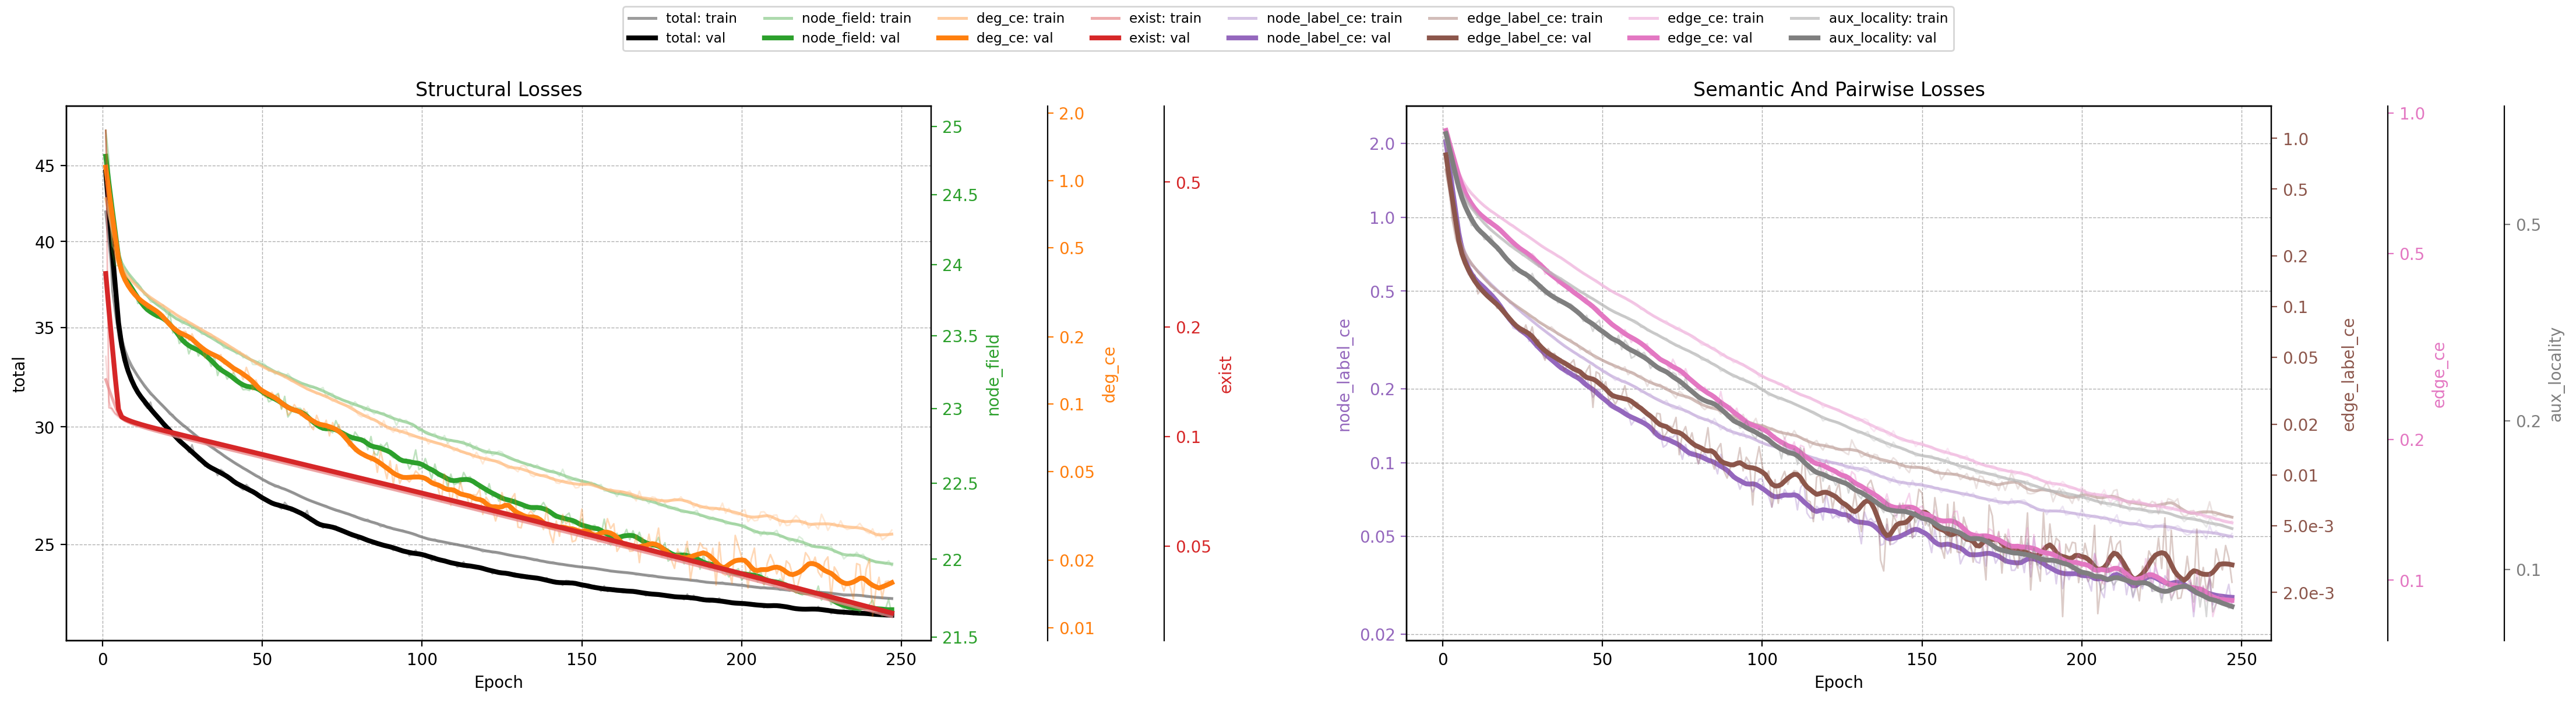

training_graph_conditioning_ = 9000
is_fitted_ = True
CPU times: user 37min 28s, sys: 1min 47s, total: 39min 16s
Wall time: 32min 10s


In [5]:
%%time
graph_generator.fit(
    graphs,
    sample_training_progress=False,
    sample_training_progress_n_samples=1,
    sample_training_progress_every_n_epochs=30,
    sample_training_progress_pdf_path=TRAINING_PROGRESS_PDF_PATH,
    sample_training_progress_plot_fn=plot_artificial_graphs,
)
print('training_graph_conditioning_ =', len(graph_generator.training_graph_conditioning_))
print('is_fitted_ =', graph_generator.is_fitted_)


In [ ]:
# Optional reload path for a previously saved artificial non-streaming model.
from conditional_node_field_graph_generator.persistence import (
    list_saved_graph_generators,
    load_graph_generator,
)

list_saved_graph_generators(SAVED_GENERATOR_ROOT)
MODEL_FILENAME = f'{MODEL_NAME}.pkl'
graph_generator = load_graph_generator(MODEL_FILENAME, model_dir=SAVED_GENERATOR_ROOT)


In [ ]:
n_samples = 3
sample_variants = graph_generator.sample(n_samples, return_decode_stages=True)

for variant_key, title_prefix in (
    ('raw', 'raw'),
    ('ilp', 'ilp'),
    ('oracle', 'oracle ilp'),
):
    variant_samples = sample_variants[variant_key]
    plot_artificial_graphs(
        variant_samples,
        n_cols=n_samples,
        titles=[f'{title_prefix} {idx}' for idx in range(len(variant_samples))],
    )

In [ ]:
if graph_generator.feasibility_estimator is None:
    print('Feasibility estimator is unavailable in this environment; skipping filtered sampling.')
else:
    filtered_samples = graph_generator.sample(
        n_samples=n_samples,
        apply_feasibility_filtering=True,
    )
    plot_artificial_graphs(
        filtered_samples,
        n_cols=n_samples,
        titles=[f'filtered {idx}' for idx in range(len(filtered_samples))],
    )
